In [1]:
# Manipulação e análise de dados
import pandas as pd  

# Visualização de dados
import seaborn as sns  
import matplotlib.pyplot as plt  

# Conexão com PostgreSQL
import psycopg2
import os

In [2]:
conn = psycopg2.connect(
    host = os.getenv("DB_HOST"),
    port = os.getenv("DB_PORT"),
    dbname = os.getenv("DB_NAME"),
    user = os.getenv("DB_USER"),
    password = os.getenv("DB_PASSWORD"),
)
cursor = conn.cursor()

  Country  Year               GDP
0  Brazil  2024  2185821648943.86
1  Brazil  2023  2191131869706.02
2  Brazil  2022  1951923832083.87
3  Brazil  2021  1670647464062.96
4  Brazil  2020  1476107292151.95


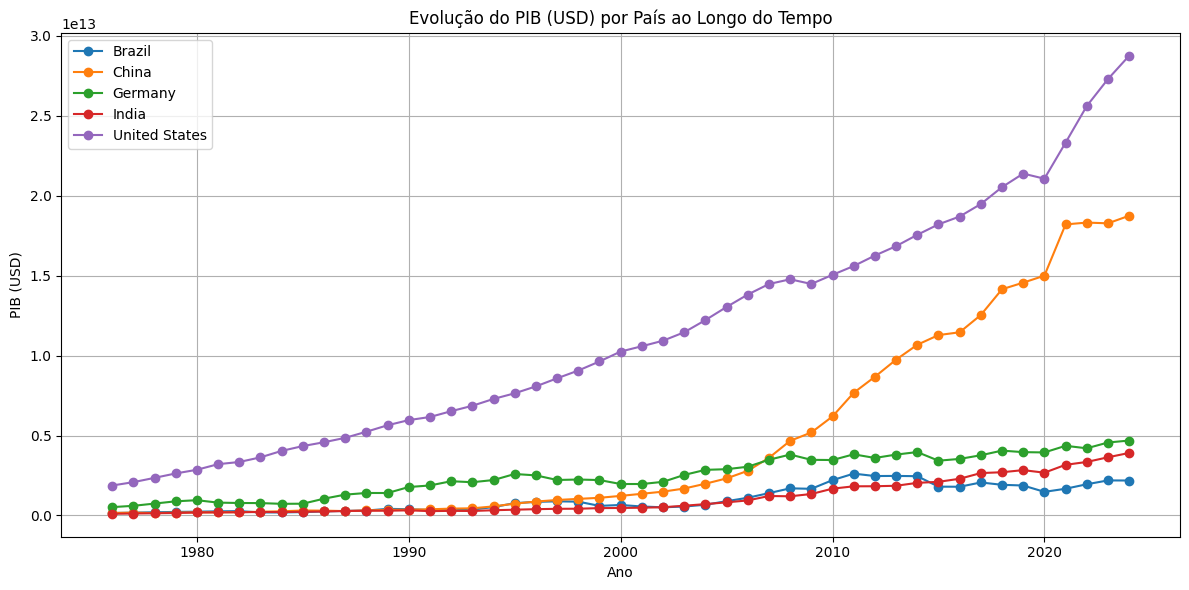

In [3]:
# Consulta: evolução do PIB (USD) por país ao longo do tempo
query = """
    SELECT
        co.country_name,      -- Nome do país (dimensão)
        fa.year,              -- Ano de referência
        fa.value AS gdp       -- PIB do país no ano (USD)
    FROM fact_indicators AS fa        -- Tabela fato com indicadores econômicos
    LEFT JOIN dim_country AS co       -- Junção com dimensão de países
        ON fa.country_id = co.country_id
    WHERE fa.indicator_id = 'NY.GDP.MKTP.CD'  -- Filtro: indicador PIB total
    ORDER BY co.country_name, fa.year DESC;   -- Ordenação por país e ano decrescente
"""

try:
    cursor.execute(query)
    results = cursor.fetchall()

    # Transformar em DataFrame
    df = pd.DataFrame(results, columns=['Country', 'Year', 'GDP'])
    print(df.head())

    # Plot: evolução do PIB por país
    plt.figure(figsize=(12, 6))
    for country in df['Country'].unique():
        country_data = df[df['Country'] == country].sort_values('Year')
        plt.plot(country_data['Year'], country_data['GDP'], marker='o', label=country)

    plt.title('Evolução do PIB (USD) por País ao Longo do Tempo')
    plt.xlabel('Ano')
    plt.ylabel('PIB (USD)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

except Exception as e:
    print("Erro na execução da query:", e)
    conn.rollback()

  Country UnemploymentRate  Year
0  Brazil             6.89  1991
1  Brazil             7.09  1992
2  Brazil             6.03  1993
3  Brazil             6.58  1994
4  Brazil             7.09  1995


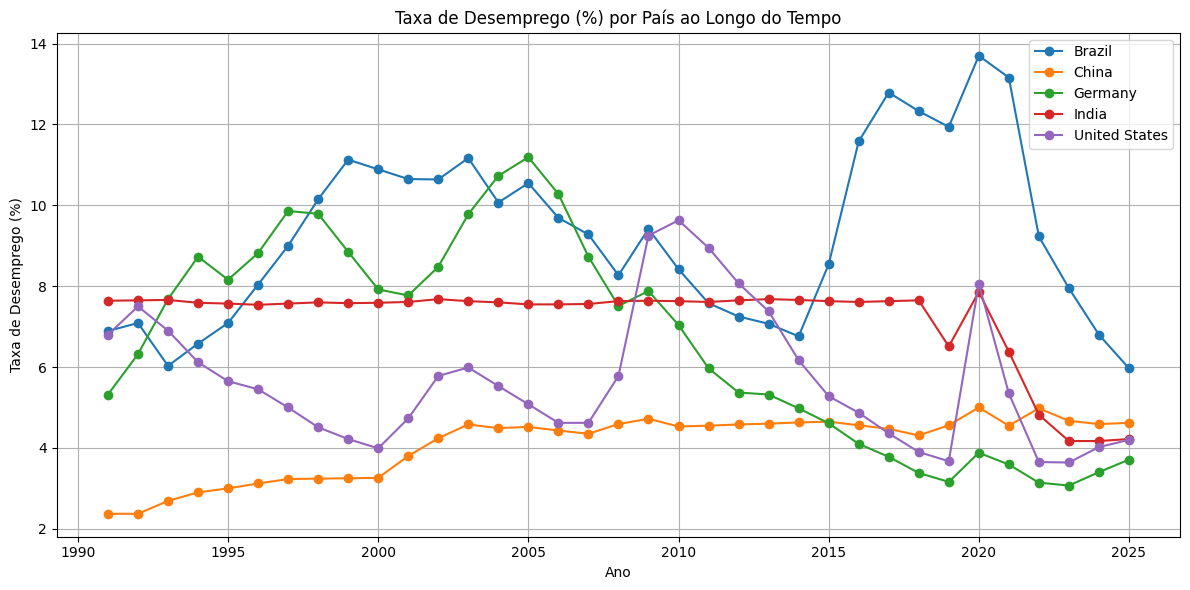

In [4]:
# Consulta: taxa de desemprego (%) por país ao longo do tempo
query = """
    SELECT
        co.country_name,              -- Nome do país (dimensão)
        fa.value AS unemployment_rate,-- Valor do indicador (% desemprego)
        fa.year                       -- Ano de referência
    FROM fact_indicators AS fa        -- Tabela fato com indicadores econômicos
    LEFT JOIN dim_country AS co       -- Junção com dimensão de países
        ON co.country_id = fa.country_id
    WHERE fa.indicator_id = 'SL.UEM.TOTL.ZS'  -- Filtro: indicador de desemprego
    ORDER BY co.country_name, fa.year;       -- Ordenação por país e ano
"""

try:
    cursor.execute(query)
    results = cursor.fetchall()

    # Transformar em DataFrame
    df = pd.DataFrame(results, columns=['Country', 'UnemploymentRate', 'Year'])
    print(df.head())

    # Plot: taxa de desemprego por país
    plt.figure(figsize=(12, 6))
    for country in df['Country'].unique():
        country_data = df[df['Country'] == country]
        plt.plot(country_data['Year'], country_data['UnemploymentRate'], marker='o', label=country)

    plt.title('Taxa de Desemprego (%) por País ao Longo do Tempo')
    plt.xlabel('Ano')
    plt.ylabel('Taxa de Desemprego (%)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

except Exception as e:
    print("Erro na execução da query:", e)
    conn.rollback()

  Country  Year LifeExpectancy GDPPerCapita
0      BR  1976          60.01      1389.75
1      BR  1977          60.46      1562.29
2      BR  1978          60.92      1732.50
3      BR  1979          61.37      1869.71
4      BR  1980          61.82      1958.57


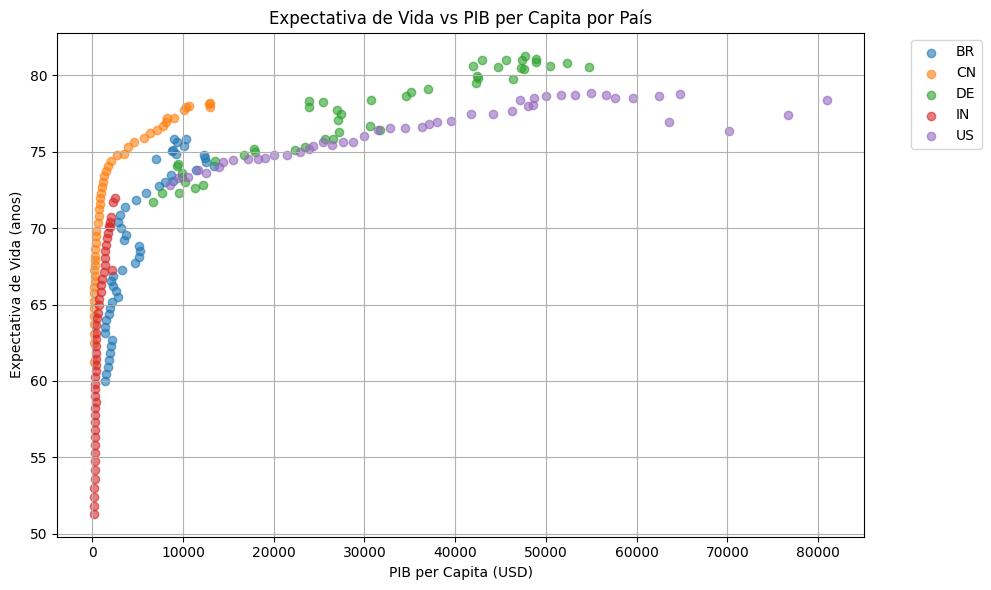

In [5]:
# Consulta: relação entre Expectativa de Vida e PIB per capita por país/ano
query = """
    SELECT
        life.country_id,                  -- Identificador do país
        life.year,                        -- Ano de referência
        life.value AS life_expectancy,    -- Expectativa de vida (anos)
        gdp.value AS gdp_per_capita       -- PIB per capita (USD)
    FROM fact_indicators AS life          -- Tabela fato (Expectativa de Vida)
    JOIN fact_indicators AS gdp           -- Auto-join na mesma fato (PIB per capita)
        ON life.country_id = gdp.country_id
        AND life.year = gdp.year          -- Garante correspondência por país e ano
    WHERE life.indicator_id = 'SP.DYN.LE00.IN'   -- Indicador: Expectativa de Vida
        AND gdp.indicator_id = 'NY.GDP.PCAP.CD'  -- Indicador: PIB per capita
    ORDER BY life.country_id, life.year; -- Ordenação temporal por país
"""

try:
    cursor.execute(query)
    results = cursor.fetchall()

    # Transformar em DataFrame
    df = pd.DataFrame(results, columns=['Country', 'Year', 'LifeExpectancy', 'GDPPerCapita'])
    print(df.head())

    # Scatter plot: Expectativa de Vida vs PIB per capita
    plt.figure(figsize=(10, 6))
    for country in df['Country'].unique():
        country_data = df[df['Country'] == country]
        plt.scatter(country_data['GDPPerCapita'], country_data['LifeExpectancy'], label=country, alpha=0.6)

    plt.title('Expectativa de Vida vs PIB per Capita por País')
    plt.xlabel('PIB per Capita (USD)')
    plt.ylabel('Expectativa de Vida (anos)')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')  # Legenda à direita
    plt.grid(True)
    plt.tight_layout()
    plt.show()

except Exception as e:
    print("Erro na execução da query:", e)
    conn.rollback()

  Country        AvgGDPGrowth
0      CN  8.7283673469387755
1      IN  5.7222448979591837
2      US  2.8048979591836735
3      BR  2.7381632653061224
4      DE  1.7455102040816327


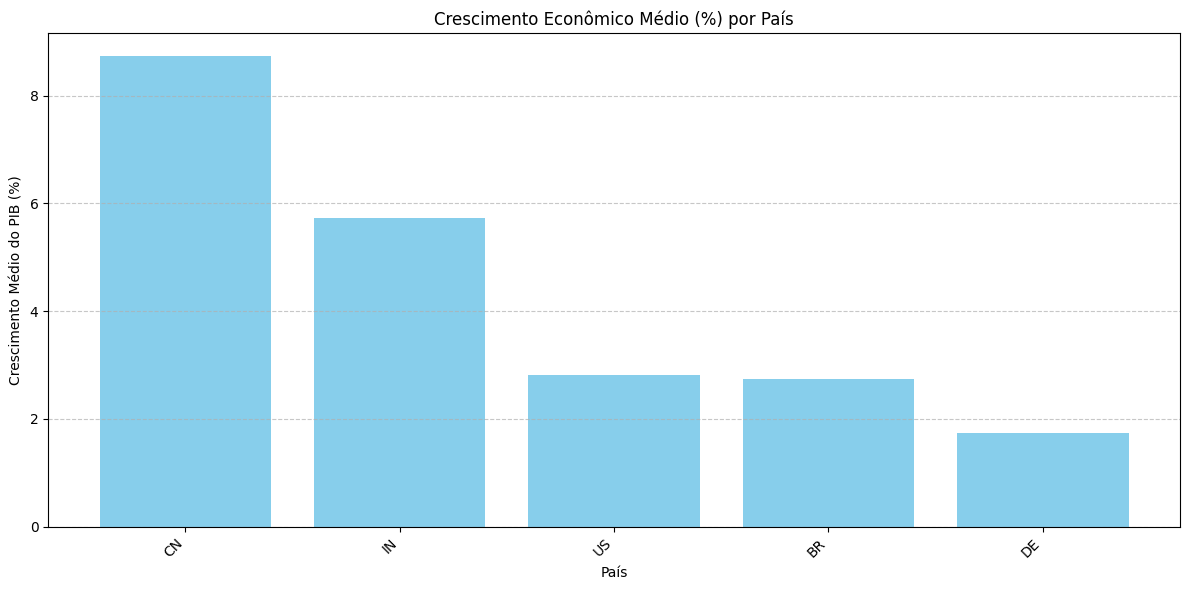

In [6]:
# Consulta: crescimento econômico médio (%) por país
query = """
    SELECT
        country_id,                         -- Identificador do país
        AVG(value) AS avg_gdp_growth        -- Média do crescimento do PIB (%)
    FROM fact_indicators                    -- Tabela fato com indicadores econômicos
    WHERE indicator_id = 'NY.GDP.MKTP.KD.ZG'-- Indicador: crescimento do PIB (anual %)
    GROUP BY country_id                     -- Agrupamento por país
    ORDER BY avg_gdp_growth DESC;           -- Ordena do maior para o menor crescimento médio
"""

try:
    cursor.execute(query)
    results = cursor.fetchall()

    # Transformar em DataFrame
    df = pd.DataFrame(results, columns=['Country', 'AvgGDPGrowth'])
    print(df.head())

    # Gráfico de barras: crescimento médio do PIB
    plt.figure(figsize=(12, 6))
    plt.bar(df['Country'], df['AvgGDPGrowth'], color='skyblue')
    plt.title('Crescimento Econômico Médio (%) por País')
    plt.xlabel('País')
    plt.ylabel('Crescimento Médio do PIB (%)')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

except Exception as e:
    print("Erro na execução da query:", e)
    conn.rollback()